In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_excel('LW-DATASET-TRATADO.xlsx')
df.shape

(122543, 28)

In [3]:
df['mes'] = df['Aberto'].dt.month

In [4]:
df['tem_AM'] = df['Descrição resumida'].str.contains('Application Monitoring', case=False, na=False).astype(int)

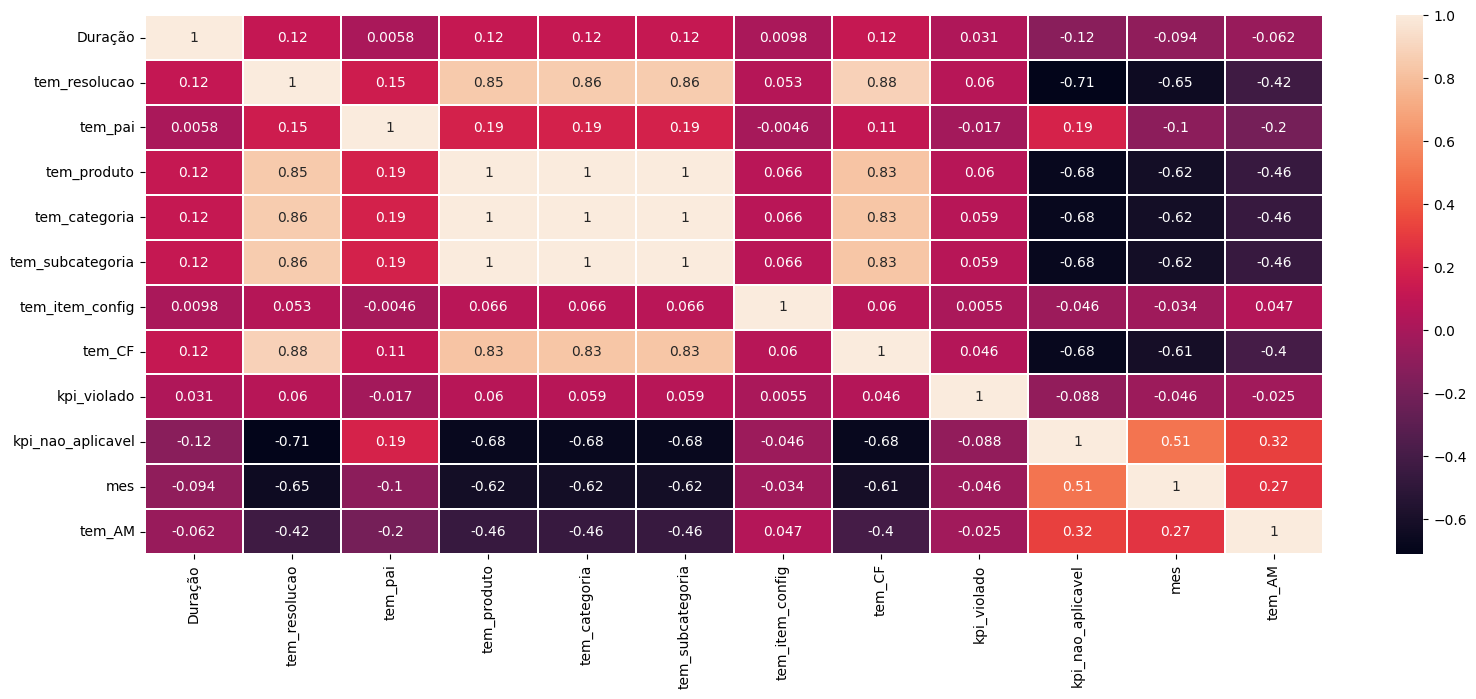

In [5]:
matriz_correlacao = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(19, 7))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2)
plt.show()

### Modelo 

Para prever volume de incidentes futuros (D+1 e D+7), a unidade de análise não deve mais ser o incidente individual, mas sim o dia.

Para o forecast preciso transformar o dataset atual em:
| Data       | qtd\_incidentes |
| ---------- | --------------: |
| 2024-01-01 |             237 |
| 2024-01-02 |             198 |
| 2024-01-03 |             214 |

Passo 1: criar série diária

In [6]:
df_model = df[df['Aberto'] >= '2025-01-01'].copy()
serie = (df_model.groupby(df_model['Aberto'].dt.date).size().reset_index(name='qtd_incidentes'))
serie.columns = ['data', 'qtd_incidentes']
serie['data'] = pd.to_datetime(serie['data'])

In [7]:
indicadores = (df.groupby(df['Aberto'].dt.date).agg({'tem_AM':'mean'}).reset_index().rename(columns={'Aberto': 'data'}))

In [8]:
serie['data'] = pd.to_datetime(serie['data'])
indicadores['data'] = pd.to_datetime(indicadores['data'])

Passo 3: Juntar tudo

In [9]:
serie = serie.merge(indicadores, on='data')

Passo 4: Criar features de séries temporais
- Lags

In [10]:
serie['lag_1'] = serie['qtd_incidentes'].shift(1)
serie['lag_7'] = serie['qtd_incidentes'].shift(7)

Médias móveis

In [11]:
serie['media_7d'] = serie['qtd_incidentes'].rolling(7).mean()

Passo 5: Calendário

In [12]:
serie['mes'] = serie['data'].dt.month
serie['dia_semana'] = serie['data'].dt.dayofweek

Passo 6: Criar os alvos

In [13]:
serie['target_d1'] = serie['qtd_incidentes'].shift(-1)
serie['target_d7'] = serie['qtd_incidentes'].shift(-7)

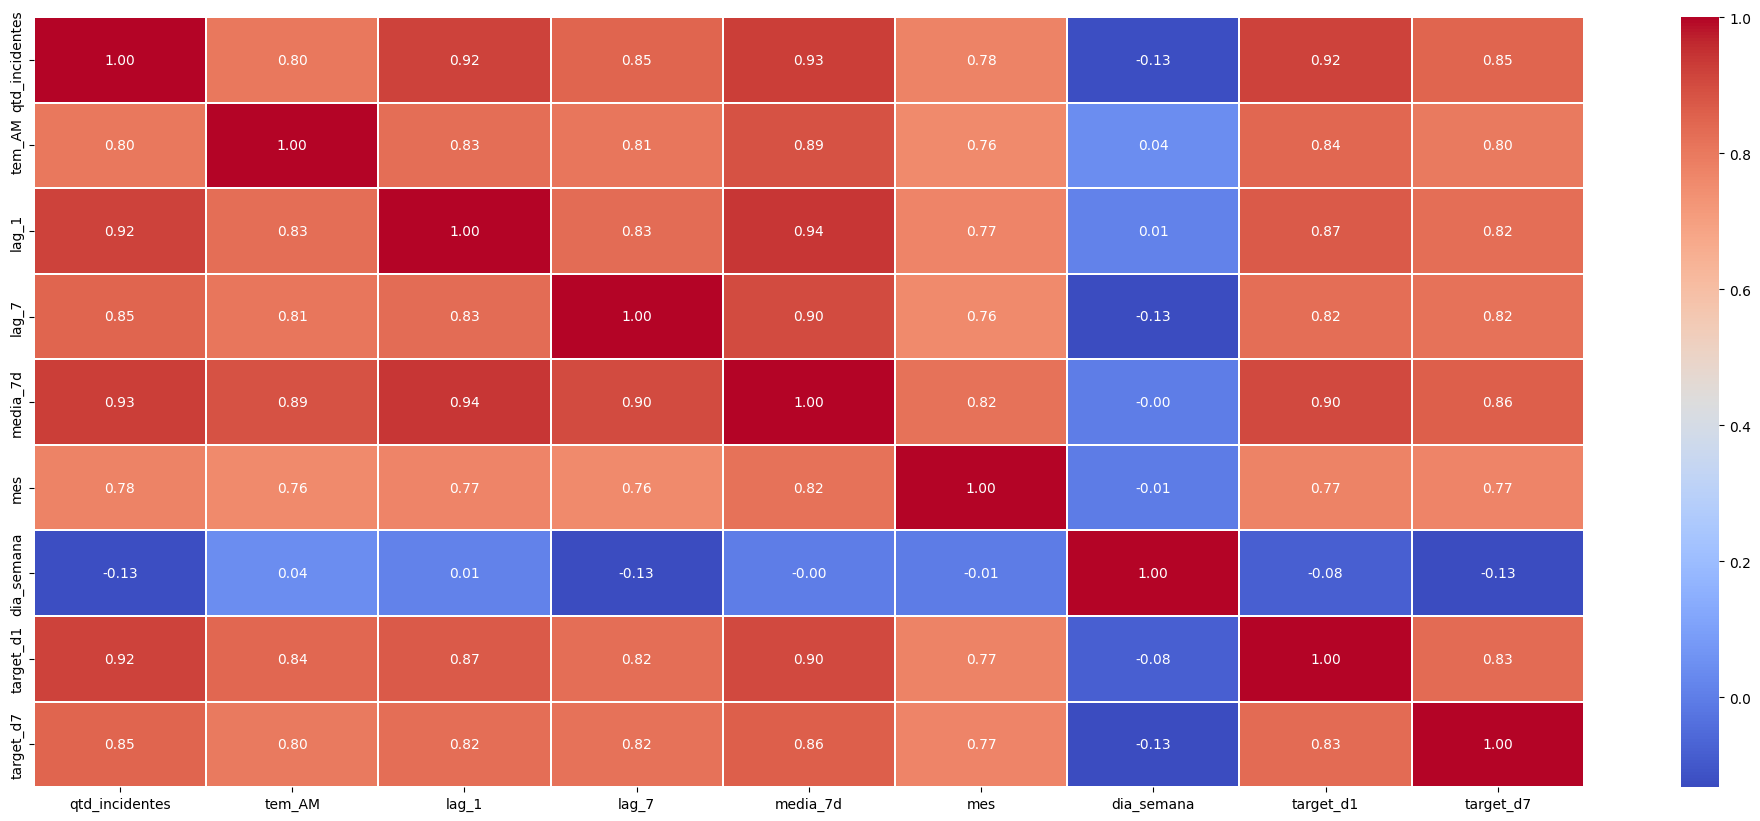

In [14]:
matriz_correlacao = serie.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(25, 10))
sns.heatmap(matriz_correlacao, annot = True, linewidths = 0.2, cmap='coolwarm', fmt='.2f')
plt.show()

Interpretação:

| Feature             | Corr com target\_d1 |
| ------------------- | ------------------- |
| lag\_1              | 0.86                |
| media\_7d           | 0.90                |
| tem\_AM             | 0.85                |
| lag\_7              | 0.82                |

##
| Feature             | Corr com target\_d7 |
| ------------------- | ------------------- |
| media\_7d           | 0.86                |
| lag\_1              | 0.82                |
| lag\_7              | 0.82                |
| tem\_AM             | 0.80                |

Essas foram outras features que eu criei, mas que **não utilizei no modelo** (apesar de terem correlação)
- modelo performou melhor sem elas

In [15]:
serie['lag_2'] = serie['qtd_incidentes'].shift(2)
serie['lag_14'] = serie['qtd_incidentes'].shift(14)
serie['lag_30'] = serie['qtd_incidentes'].shift(30)
serie['media_14d'] = serie['qtd_incidentes'].rolling(14).mean()
serie['media_30d'] = serie['qtd_incidentes'].rolling(30).mean()
serie['std_7d'] = serie['qtd_incidentes'].rolling(7).std()
serie['media_3d'] = serie['qtd_incidentes'].rolling(3).mean()
serie['trend_7_30'] = serie['media_7d'] - serie['media_30d']
serie['variacao_1d'] = serie['lag_1'] - serie['lag_2']
serie['variacao_7d'] = serie['lag_1'] - serie['lag_7']

Removendo linhas com NaN gerados pelos lags e targets:
- os NaNs são criados por conta de que não existe valor antes do primeiro do dataset (ou dos 7 primeiros etc)

In [16]:
serie_model = serie.dropna().copy()
len(serie_model)

328

#### Teste de features:

O teste foi feito com o melhor modelo encontrado para esse caso (gradient boosting)

| Features | MAE | RMSE | R2 |
|----------|-----|------|----|
| 'lag_1', 'lag_2', 'lag_7', 'media_7d', 'tem_AM', 'mes' | 118 | 157 | 0.23 |
| 'lag_1', 'lag_7', 'media_7d', 'tem_AM', 'mes' | 106 | 142 | 0.37 | 
| 'lag_1', 'lag_2', 'lag_14', 'lag_7', 'media_7d', 'tem_AM', 'mes'  | 114 | 157 | 0.23 |
| 'lag_1', 'lag_7', 'media_7d', 'media_3d', 'tem_AM', 'mes' | 118 | 163 | 0.17 |
| 'lag_1', 'lag_7', 'media_7d', 'media_14d' ,'tem_AM', 'mes' | 155 | 205 | -0.29 |
| 'tem_AM', 'media_3d', 'media_14d', 'media_30d', 'mes', 'dia_semana' | 173 | 235 | -0.71 |
| 'lag_1', 'lag_7', 'media_7d', 'media_30d' ,'tem_AM', 'mes' | 135 | 179 | 0.00 |
| 'lag_1', 'lag_7', 'media_7d', 'trend_7_30' ,'tem_AM', 'mes' | 106 | 144 | 0.35 |
| 'lag_1', 'lag_7', 'media_7d', 'std_7d', 'tem_AM', 'mes' | 119 | 162 | 0.18 |
| 'lag_1', 'lag_7', 'media_7d', 'std_7d', 'tem_AM', 'mes', 'trend_7_30' | 122| 169 | 0.11 |
| 'lag_1', 'lag_7', 'media_7d', 'tem_AM' | 107 | 144 | 0.35 |

Features finais:

In [17]:
features = ['lag_1', 'lag_7', 'media_7d', 'tem_AM', 'mes']

``Separação temporal``

In [18]:
split = int(len(serie_model) * 0.8)

train = serie_model.iloc[:split]
test = serie_model.iloc[split:]

### Modelo D+1

| Algoritmo testado | MAE | RMSE | R2 |
|---------------------|---------|---------|---------|
| GradientBoostingRegressor | **106.19** | **142.32** | **0.375** |
| XGBRegressor | 123.76 | 162.79 | 0.182 |
| RandomForestRegressor | 125.54 | 160.48 | 0.205 |
| AdaBoostRegressor | 135.95 | 178.14 | 0.021 |
| ExtraTreesRegressor | 137.35 | 175.55 | 0.049 |

In [19]:
X_train = train[features]
X_test = test[features]

y_train = train['target_d1']
y_test = test['target_d1']

Gradient Boosting Regressor

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
model_d1 = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.03, random_state=42)

model_d1.fit(X_train, y_train)
pred_d1 = model_d1.predict(X_test)

print('MAE:', mean_absolute_error(y_test, pred_d1))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_d1)))
print('R²:', r2_score(y_test, pred_d1))

mape = np.mean(np.abs((y_test - pred_d1) / y_test)) * 100
print(f'MAPE: {mape:.2f}%')

MAE: 106.19048479581187
RMSE: 142.31539629278473
R²: 0.37498421731306764
MAPE: 13.64%


Salvando CSV

In [21]:
df_previsoes = pd.DataFrame({
    'Data': test['data'],
    'Incidentes_Previstos': pred_d1.round(0).astype(int),
    'Incidentes_Reais': y_test.values})

df_previsoes = df_previsoes.sort_values('Data')

display(df_previsoes.head())

df_previsoes.to_csv('previsao_incidentes_d1.csv', index=False)

,Data,Incidentes_Previstos,Incidentes_Reais
292,2025-10-20,683,711.0
293,2025-10-21,644,857.0
294,2025-10-22,781,756.0
295,2025-10-23,821,1022.0
296,2025-10-24,779,599.0


``Baseline D+1``

In [25]:
baseline = test['lag_1']

print('BASELINE (D+1 = Hoje)')
print('MAE:', mean_absolute_error(y_test, baseline))
print('RMSE:', np.sqrt(mean_squared_error(y_test, baseline)))
print('R²:', r2_score(y_test, baseline))

mape = np.mean(np.abs((y_test - baseline) / y_test)) * 100
print(f'MAPE: {mape:.2f}%')

BASELINE (D+1 = Hoje)
MAE: 164.28787878787878
RMSE: 225.98514968640723
R²: -0.6169801502654928
MAPE: 20.02%


### Modelo D+7

Teste de Features:
| Features | MAE | RMSE | R2 |
|----------|-----|------|----|
| 'lag_1', 'lag_7', 'media_7d', 'tem_AM' | 133 | 170 | 0.08 |
| 'lag_1', 'lag_7', 'media_7d', 'tem_AM', 'mes' | 128 | 165 | 0.12 |
| 'lag_1', 'lag_7', 'media_7d', 'trend_7_30' ,'tem_AM', 'mes' | 145 | 177 | 0.0 | 
| 'lag_1', 'lag_2', 'lag_7', 'media_7d', 'tem_AM', 'mes'  | 128 | 165 | 0.13 |
| 'lag_1', 'lag_2', 'lag_14', 'lag_7', 'media_7d', 'tem_AM', 'mes' | 131 | 165 | 0.12 |

In [23]:
features = ['lag_1', 'lag_7', 'media_7d', 'tem_AM', 'mes']
X_train = train[features]
X_test = test[features]

y_train = train['target_d7']
y_test = test['target_d7']

Teste de Modelos

| Algoritmo | MAE | RMSE | R² |
|-----------|---------|---------|---------|
| GradientBoostingRegressor | **128.60** | **165.83** | **0.129** |
| RandomForestRegressor | 132.13 | 167.54 | 0.111 |
| ExtraTreesRegressor | 131.99 | 172.69 | 0.056 |
| XGBRegressor | 136.37 | 175.94 | 0.020 |
| HistGradientBoostingRegressor | 142.35 | 185.56 | -0.090 |

In [23]:
model_d7 = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05, 
    random_state=42)

model_d7.fit(X_train, y_train)
pred_d7 = model_d7.predict(X_test)

print('MAE:', mean_absolute_error(y_test, pred_d7))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_d7)))
print('R²:', r2_score(y_test, pred_d7))

mape = np.mean(np.abs((y_test - pred_d7) / y_test)) * 100
print(f'MAPE: {mape:.2f}%')

pd.DataFrame({
    'feature': features,
    'importance': model_d7.feature_importances_
}).sort_values('importance', ascending=False)

MAE: 128.59880669498216
RMSE: 165.829596872635
R²: 0.129299133652662
MAPE: 16.15%


,feature,importance
0,lag_1,0.564091
4,mes,0.177610
2,media_7d,0.147576
1,lag_7,0.101139
3,tem_AM,0.009584


In [24]:
df_previsoes_d7 = pd.DataFrame({
    'Data': test['data'],
    'Incidentes_Previstos_D7': pred_d7.round(0).astype(int),
    'Incidentes_Reais_D7': y_test.values})

df_previsoes_d7 = df_previsoes_d7.sort_values('Data')
display(df_previsoes_d7.head())
df_previsoes_d7.to_csv('previsao_incidentes_d7.csv', index=False)

,Data,Incidentes_Previstos_D7,Incidentes_Reais_D7
292,2025-10-20,705,568.0
293,2025-10-21,713,678.0
294,2025-10-22,809,616.0
295,2025-10-23,857,624.0
296,2025-10-24,735,764.0


``Baseline D+7``

In [27]:
baseline = test['lag_7']

print('Baseline D+7')
print('MAE:', mean_absolute_error(y_test, baseline))
print('RMSE:', np.sqrt(mean_squared_error(y_test, baseline)))
print('R²:', r2_score(y_test, baseline))

mape = np.mean(np.abs((y_test - baseline) / y_test)) * 100
print(f'MAPE: {mape:.2f}%')

Baseline D+7
MAE: 171.42424242424244
RMSE: 214.7834709514198
R²: -0.46065146767465004
MAPE: 20.81%
